# Assignment 4: Fraud Detection using GANs Guidelines


*   Akarsh Dubey CS25MTECH14001
*   Atish Kadam CS25MTECH14003

# Credit Card Fraud Detection using GAN-based Unsupervised Anomaly Detection


## 0.Upload creditcard.csv (Google Colab)


In [1]:
# --- Google Colab upload helper ---
# If you are running on Google Colab, uncomment the next block to upload creditcard.csv.
# After upload it will be saved at /content/creditcard.csv.
try:
    from google.colab import files  # type: ignore
    import shutil, os
    print("Google Colab detected. Please choose creditcard.csv to upload...")
    uploaded = files.upload()
    for fname in uploaded.keys():
        dst = "/content/" + fname
        if os.path.abspath(fname) != os.path.abspath(dst):
            shutil.move(fname, dst)
        print("Saved to:", dst)
except Exception as e:
    print("Not running on Colab or upload skipped:", e)

'\ntry:\n    from google.colab import files  # type: ignore\n    import shutil, os\n    print("Google Colab detected. Please choose creditcard.csv to upload...")\n    uploaded = files.upload()\n    for fname in uploaded.keys():\n        dst = "/content/" + fname\n        if os.path.abspath(fname) != os.path.abspath(dst):\n            shutil.move(fname, dst)\n        print("Saved to:", dst)\nexcept Exception as e:\n    print("Not running on Colab or upload skipped:", e)\n'

## 1. Setup — Imports, Seeds, Device

In [2]:
import os, time, warnings
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, precision_recall_curve, auc,
    confusion_matrix, classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("PyTorch:", torch.__version__)


Device: cuda
PyTorch: 2.10.0+cu128


## 2. Data Loading


In [3]:
# Try candidate paths in order
candidate_paths = [
    "creditcard.csv",
    "/content/creditcard.csv",
]

DATA_PATH = None
for p in candidate_paths:
    if os.path.exists(p):
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find creditcard.csv. Upload it to /content/ (Colab) "
        "or place it next to this notebook."
    )

print("Loading from:", DATA_PATH)
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print()
print("Class distribution:")
print(df["Class"].value_counts())
fraud_ratio = df["Class"].mean()
print(f"Fraud ratio: {fraud_ratio:.6f}  ({fraud_ratio*100:.4f}%)")


Loading from: creditcard.csv
Shape: (284807, 31)

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud ratio: 0.001727  (0.1727%)


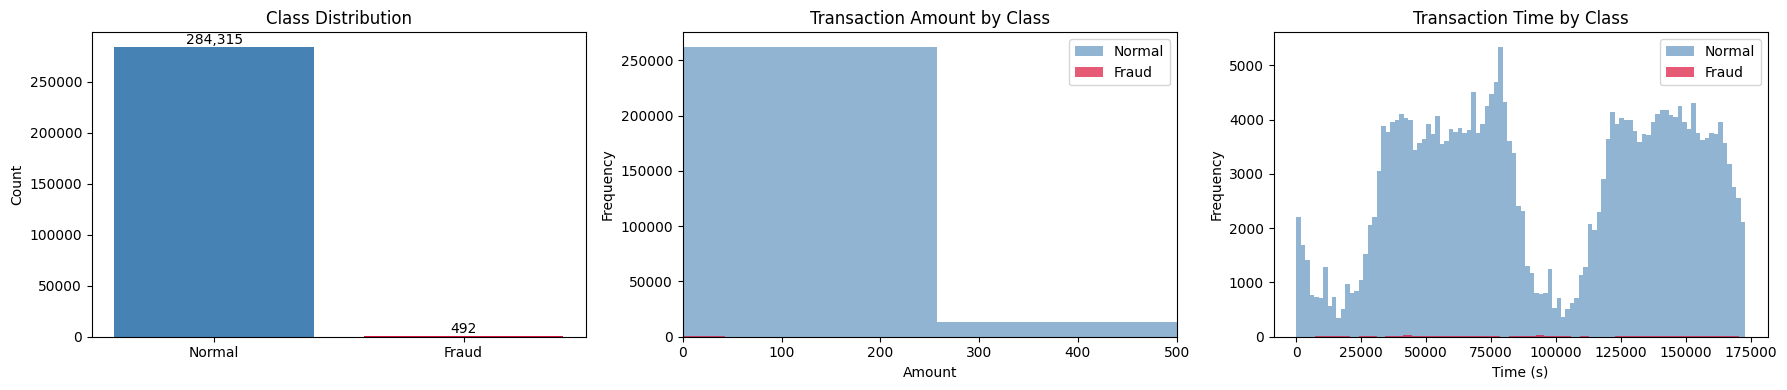

In [4]:
# EDA: 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# 1. Class distribution
counts = df["Class"].value_counts().sort_index()
axes[0].bar(["Normal", "Fraud"], counts.values, color=["steelblue", "crimson"])
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

# 2. Amount overlay
axes[1].hist(df.loc[df["Class"]==0, "Amount"], bins=100, color="steelblue", alpha=0.6, label="Normal")
axes[1].hist(df.loc[df["Class"]==1, "Amount"], bins=50,  color="crimson",   alpha=0.7, label="Fraud")
axes[1].set_xlim(0, 500)
axes[1].set_title("Transaction Amount by Class")
axes[1].set_xlabel("Amount"); axes[1].set_ylabel("Frequency")
axes[1].legend()

# 3. Time overlay
axes[2].hist(df.loc[df["Class"]==0, "Time"], bins=100, color="steelblue", alpha=0.6, label="Normal")
axes[2].hist(df.loc[df["Class"]==1, "Time"], bins=50,  color="crimson",   alpha=0.7, label="Fraud")
axes[2].set_title("Transaction Time by Class")
axes[2].set_xlabel("Time (s)"); axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.tight_layout()
plt.show()


## 3. Data Splitting (BEFORE any scaling — prevents data leakage)


In [5]:
feature_cols = [c for c in df.columns if c != "Class"]
X_all = df[feature_cols].values.astype(np.float32)   # (284807, 30)
y_all = df["Class"].values.astype(np.int64)

X_normal = X_all[y_all == 0]
X_fraud  = X_all[y_all == 1]
print("Normals:", X_normal.shape[0], "  Frauds:", X_fraud.shape[0])

# Normal split: train (75%) vs rest (25%)
X_norm_train_raw, X_norm_rest = train_test_split(
    X_normal, test_size=0.25, random_state=SEED
)
# rest: 40% val (~10% of total), 60% test (~15% of total)
X_norm_val_raw, X_norm_test_raw = train_test_split(
    X_norm_rest, test_size=0.60, random_state=SEED
)

# Fraud split: 50/50 val/test
X_fraud_val_raw, X_fraud_test_raw = train_test_split(
    X_fraud, test_size=0.50, random_state=SEED
)

print("Normal -> train:", X_norm_train_raw.shape[0],
      " val:", X_norm_val_raw.shape[0],
      " test:", X_norm_test_raw.shape[0])
print("Fraud  ->         val:", X_fraud_val_raw.shape[0],
      " test:", X_fraud_test_raw.shape[0])
print("No fraud samples in training set.")


Normals: 284315   Frauds: 492
Normal -> train: 213236  val: 28431  test: 42648
Fraud  ->         val: 246  test: 246
No fraud samples in training set.


## 4. Preprocessing (Leak-Free Two-Stage Scaling)

- **Stage 1**: `RobustScaler` on `Time` (col 0) and `Amount` (col 29) — fit on train normals only.
- **Stage 2**: `StandardScaler` on all 30 features — fit on Stage-1 train normals only.
- All other splits use `.transform()` only.

In [6]:
# Stage 1 -- RobustScaler on Time (col 0) and Amount (col 29)
rb_time   = RobustScaler().fit(X_norm_train_raw[:, [0]])
rb_amount = RobustScaler().fit(X_norm_train_raw[:, [29]])

def apply_robust_scaling(X):
    Xc = X.copy()
    Xc[:, [0]]  = rb_time.transform(Xc[:, [0]])
    Xc[:, [29]] = rb_amount.transform(Xc[:, [29]])
    return Xc

X_norm_train_rb = apply_robust_scaling(X_norm_train_raw)
X_norm_val_rb   = apply_robust_scaling(X_norm_val_raw)
X_norm_test_rb  = apply_robust_scaling(X_norm_test_raw)
X_fraud_val_rb  = apply_robust_scaling(X_fraud_val_raw)
X_fraud_test_rb = apply_robust_scaling(X_fraud_test_raw)

# Stage 2 -- StandardScaler over all 30 features (fit on train normals)
ss = StandardScaler().fit(X_norm_train_rb)

X_normal_train = ss.transform(X_norm_train_rb).astype(np.float32)
X_normal_val   = ss.transform(X_norm_val_rb).astype(np.float32)
X_normal_test  = ss.transform(X_norm_test_rb).astype(np.float32)
X_fraud_val    = ss.transform(X_fraud_val_rb).astype(np.float32)
X_fraud_test   = ss.transform(X_fraud_test_rb).astype(np.float32)

print("X_normal_train:", X_normal_train.shape)
print("X_normal_val:",   X_normal_val.shape,
      " X_normal_test:", X_normal_test.shape)
print("X_fraud_val:",    X_fraud_val.shape,
      " X_fraud_test:",  X_fraud_test.shape)
print(f"Train normals -- mean: {X_normal_train.mean():.6f}  std: {X_normal_train.std():.6f}")


X_normal_train: (213236, 30)
X_normal_val: (28431, 30)  X_normal_test: (42648, 30)
X_fraud_val: (246, 30)  X_fraud_test: (246, 30)
Train normals -- mean: -0.000000  std: 1.000000


In [7]:
# Assemble Val and Test sets and shuffle
X_val = np.vstack([X_normal_val, X_fraud_val]).astype(np.float32)
y_val = np.hstack([np.zeros(len(X_normal_val), int),
                   np.ones(len(X_fraud_val),  int)])
perm_v = np.random.permutation(len(X_val))
X_val, y_val = X_val[perm_v], y_val[perm_v]

X_test = np.vstack([X_normal_test, X_fraud_test]).astype(np.float32)
y_test = np.hstack([np.zeros(len(X_normal_test), int),
                    np.ones(len(X_fraud_test),  int)])
perm_t = np.random.permutation(len(X_test))
X_test, y_test = X_test[perm_t], y_test[perm_t]

print("X_val:",  X_val.shape,  " frauds in val:",  int(y_val.sum()))
print("X_test:", X_test.shape, " frauds in test:", int(y_test.sum()))


X_val: (28677, 30)  frauds in val: 246
X_test: (42894, 30)  frauds in test: 246


## 5. Hyper-parameters & DataLoaders

In [8]:
# ---- Common ----
INPUT_DIM  = 30
LATENT_DIM = 32

# ---- BiGAN ----
BIGAN_BATCH    = 512
BIGAN_EPOCHS   = 100
BIGAN_LR_GE    = 2e-4
BIGAN_LR_D     = 1e-4         # TTUR: D slower
BIGAN_RECON_W  = 5.0
BIGAN_SMOOTH   = 0.9          # label smoothing
BIGAN_NOISE    = 0.1          # instance noise std
BIGAN_LAMBDA   = 0.1
BIGAN_LATENT_W = 0.5

# ---- AnoGAN ----
ANOGAN_BATCH    = 256
ANOGAN_EPOCHS   = 100
ANOGAN_LR_G     = 2e-4
ANOGAN_LR_D     = 1e-4        # TTUR
ANOGAN_SMOOTH   = 0.9
ANOGAN_NOISE    = 0.1
ANOGAN_N_CRITIC = 1
ANOGAN_Z_LR     = 0.01
ANOGAN_Z_ITERS  = 500
ANOGAN_LAMBDA   = 0.1
ANOGAN_OPT_BS   = 128

# ---- DataLoaders ----
train_tensor = torch.from_numpy(X_normal_train).float()

bigan_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=BIGAN_BATCH, shuffle=True, drop_last=True, num_workers=0
)
anogan_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=ANOGAN_BATCH, shuffle=True, drop_last=True, num_workers=0
)

X_val_tensor  = torch.from_numpy(X_val).float().to(DEVICE)
X_test_tensor = torch.from_numpy(X_test).float().to(DEVICE)

print("BiGAN  batches/epoch:", len(bigan_loader))
print("AnoGAN batches/epoch:", len(anogan_loader))


BiGAN  batches/epoch: 416
AnoGAN batches/epoch: 832


## 6. Evaluation Utilities

- `find_threshold_on_val`: F1-optimal threshold from validation precision-recall curve.
- `evaluate_model`: full metrics + confusion matrix + classification report.
- `plot_diagnostics`: 4-panel diagnostic figure.
- **No peeking**: thresholds set on validation only, then applied once to test.

In [9]:
def find_threshold_on_val(y_val, val_scores, model_name):
    precisions, recalls, thresholds = precision_recall_curve(y_val, val_scores)
    f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)
    # Drop the trailing point (no threshold for it)
    f1s_t = f1s[:-1] if len(f1s) > len(thresholds) else f1s
    best_idx = int(np.argmax(f1s_t))
    if best_idx >= len(thresholds):
        best_thresh = float(thresholds[-1])
    else:
        best_thresh = float(thresholds[best_idx])
    print(f"[{model_name}] best validation threshold = {best_thresh:.6f}  "
          f"(val F1 = {f1s_t[best_idx]:.4f})")
    return best_thresh


def evaluate_model(y_true, scores, model_name, threshold):
    y_pred = (scores >= threshold).astype(int)
    acc  = accuracy_score (y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score   (y_true, y_pred, zero_division=0)
    f1   = f1_score       (y_true, y_pred, zero_division=0)
    roc  = roc_auc_score  (y_true, scores)
    p_curve, r_curve, _ = precision_recall_curve(y_true, scores)
    auprc = auc(r_curve, p_curve)
    cm    = confusion_matrix(y_true, y_pred)

    print("=" * 60)
    print(f"  {model_name}  --  Test Set Results")
    print("=" * 60)
    print(f"  Threshold : {threshold:.6f}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {roc:.4f}")
    print(f"  AUPRC     : {auprc:.4f}")
    print()
    print("  Confusion matrix:")
    print(cm)
    print()
    print(classification_report(y_true, y_pred,
                                target_names=["Normal", "Fraud"],
                                digits=4))
    print("=" * 60)

    return {
        "name": model_name,
        "threshold": threshold,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc,
        "auprc": auprc,
        "scores": scores,
        "y_pred": y_pred,
        "confusion_matrix": cm,
    }


def plot_diagnostics(y_true, results):
    scores    = results["scores"]
    threshold = results["threshold"]
    name      = results["name"]
    cm        = results["confusion_matrix"]

    fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

    # 1. Score distribution
    axes[0].hist(scores[y_true == 0], bins=80, color="steelblue",
                 alpha=0.6, label="Normal")
    axes[0].hist(scores[y_true == 1], bins=40, color="crimson",
                 alpha=0.8, label="Fraud")
    axes[0].axvline(threshold, color="black", linestyle="--",
                    label=f"thr={threshold:.3f}")
    axes[0].set_title(f"{name} -- Score Distribution")
    axes[0].set_xlabel("Anomaly Score"); axes[0].set_ylabel("Count")
    axes[0].legend()

    # 2. ROC
    fpr, tpr, _ = roc_curve(y_true, scores)
    axes[1].plot(fpr, tpr, color="steelblue",
                 label=f"AUC = {results['roc_auc']:.4f}")
    axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
    axes[1].set_title(f"{name} -- ROC")
    axes[1].set_xlabel("FPR"); axes[1].set_ylabel("TPR")
    axes[1].legend(); axes[1].grid(alpha=0.3)

    # 3. PR
    p, r, _ = precision_recall_curve(y_true, scores)
    axes[2].plot(r, p, color="darkorange",
                 label=f"AUPRC = {results['auprc']:.4f}")
    axes[2].set_title(f"{name} -- Precision-Recall")
    axes[2].set_xlabel("Recall"); axes[2].set_ylabel("Precision")
    axes[2].legend(); axes[2].grid(alpha=0.3)

    # 4. Confusion matrix
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Fraud"],
                yticklabels=["Normal", "Fraud"],
                ax=axes[3], cbar=False)
    axes[3].set_title(f"{name} -- Confusion Matrix")
    axes[3].set_xlabel("Predicted"); axes[3].set_ylabel("Actual")

    plt.tight_layout()
    plt.show()


## 7. BiGAN (Bidirectional GAN)

Trains G, E, D jointly. D classifies joint pairs (x, z). The encoder learns G's inverse so that x ≈ G(E(x)).

**Anomaly score**:
$$A(x) = (1-\lambda)\big[\|x - G(E(x))\|_1 + w_{lat}\,\|E(x)-E(G(E(x)))\|_1\big] + \lambda\,\|f_D(x,E(x))-f_D(G(E(x)),E(x))\|_1$$
with $\lambda=0.1$, $w_{lat}=0.5$.

### 7.1 Architecture

In [10]:
class BiGAN_Generator(nn.Module):
    """z (32) -> x_hat (30)."""
    def __init__(self, latent_dim=LATENT_DIM, output_dim=INPUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, output_dim),
        )

    def forward(self, z):
        return self.net(z)


class BiGAN_Encoder(nn.Module):
    """x (30) -> z_hat (32)."""
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(64, latent_dim),
        )

    def forward(self, x):
        return self.net(x)


class BiGAN_Discriminator(nn.Module):
    """(x, z) -> raw logit.  Penultimate 'joint' features (64-d) exposed."""
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.x_branch = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),
        )
        self.z_branch = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.5),
        )
        self.joint = nn.Sequential(
            nn.Linear(128 + 64, 64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
        )
        self.head = nn.Linear(64, 1)   # raw logit (no sigmoid)

    def forward(self, x, z, return_features=False):
        hx = self.x_branch(x)
        hz = self.z_branch(z)
        h  = torch.cat([hx, hz], dim=1)
        feat = self.joint(h)
        logit = self.head(feat)
        if return_features:
            return logit, feat
        return logit


G_bi = BiGAN_Generator().to(DEVICE)
E_bi = BiGAN_Encoder().to(DEVICE)
D_bi = BiGAN_Discriminator().to(DEVICE)

def n_params(m):
    return sum(p.numel() for p in m.parameters())

print(f"BiGAN G params: {n_params(G_bi):,}")
print(f"BiGAN E params: {n_params(E_bi):,}")
print(f"BiGAN D params: {n_params(D_bi):,}")


BiGAN G params: 14,686
BiGAN E params: 14,304
BiGAN D params: 18,497


### 7.2 Training

In [11]:
opt_GE   = optim.Adam(list(G_bi.parameters()) + list(E_bi.parameters()),
                       lr=BIGAN_LR_GE, betas=(0.5, 0.999))
opt_D_bi = optim.Adam(D_bi.parameters(),
                       lr=BIGAN_LR_D,  betas=(0.5, 0.999))

bce_logits = nn.BCEWithLogitsLoss()

hist_d, hist_ge, hist_recon = [], [], []

t0 = time.time()
for epoch in range(BIGAN_EPOCHS):
    G_bi.train(); E_bi.train(); D_bi.train()

    noise_std = BIGAN_NOISE * max(0.0, 1 - epoch / BIGAN_EPOCHS)

    e_d, e_ge, e_recon = 0.0, 0.0, 0.0
    n_batches = 0

    for (x_real,) in bigan_loader:
        x_real = x_real.to(DEVICE)
        bsz = x_real.size(0)
        smooth_real = torch.full((bsz, 1), BIGAN_SMOOTH, device=DEVICE)
        zeros = torch.zeros((bsz, 1), device=DEVICE)
        ones  = torch.ones ((bsz, 1), device=DEVICE)

        # ---------------- D step ----------------
        with torch.no_grad():
            z_fake = torch.randn(bsz, LATENT_DIM, device=DEVICE)
            x_fake = G_bi(z_fake)
            z_real = E_bi(x_real)

        x_real_n = x_real + noise_std * torch.randn_like(x_real)
        x_fake_n = x_fake + noise_std * torch.randn_like(x_fake)

        d_real = D_bi(x_real_n, z_real)
        d_fake = D_bi(x_fake_n, z_fake)
        d_loss = bce_logits(d_real, smooth_real) + bce_logits(d_fake, zeros)

        opt_D_bi.zero_grad()
        d_loss.backward()
        torch.nn.utils.clip_grad_norm_(D_bi.parameters(), max_norm=5.0)
        opt_D_bi.step()

        # --------------- G + E step --------------
        z_fake2 = torch.randn(bsz, LATENT_DIM, device=DEVICE)
        x_fake2 = G_bi(z_fake2)
        z_real2 = E_bi(x_real)

        ge_real = D_bi(x_real, z_real2)
        ge_fake = D_bi(x_fake2, z_fake2)
        # Flip labels for the G+E adversarial loss
        adv_loss = bce_logits(ge_real, zeros) + bce_logits(ge_fake, ones)

        x_recon = G_bi(E_bi(x_real))
        recon_loss = (x_real - x_recon).abs().mean()

        ge_loss = adv_loss + BIGAN_RECON_W * recon_loss

        opt_GE.zero_grad()
        ge_loss.backward()
        torch.nn.utils.clip_grad_norm_(
            list(G_bi.parameters()) + list(E_bi.parameters()), max_norm=5.0
        )
        opt_GE.step()

        e_d     += d_loss.item()
        e_ge    += ge_loss.item()
        e_recon += recon_loss.item()
        n_batches += 1

    e_d, e_ge, e_recon = e_d / n_batches, e_ge / n_batches, e_recon / n_batches
    hist_d.append(e_d); hist_ge.append(e_ge); hist_recon.append(e_recon)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"[BiGAN] epoch {epoch+1:3d}/{BIGAN_EPOCHS}  "
              f"D={e_d:.4f}  GE={e_ge:.4f}  recon={e_recon:.4f}  "
              f"noise={noise_std:.3f}")

print(f"BiGAN training time: {(time.time()-t0)/60:.2f} min")


[BiGAN] epoch   1/100  D=1.0534  GE=4.5439  recon=0.4883  noise=0.100
[BiGAN] epoch  10/100  D=1.2667  GE=3.1878  recon=0.3007  noise=0.091
[BiGAN] epoch  20/100  D=1.2423  GE=3.2941  recon=0.2833  noise=0.081
[BiGAN] epoch  30/100  D=1.2816  GE=3.1581  recon=0.2721  noise=0.071
[BiGAN] epoch  40/100  D=1.2827  GE=3.0772  recon=0.2622  noise=0.061
[BiGAN] epoch  50/100  D=1.2980  GE=2.9934  recon=0.2532  noise=0.051
[BiGAN] epoch  60/100  D=1.2899  GE=2.9843  recon=0.2457  noise=0.041
[BiGAN] epoch  70/100  D=1.2965  GE=2.9097  recon=0.2386  noise=0.031
[BiGAN] epoch  80/100  D=1.2893  GE=2.9053  recon=0.2336  noise=0.021
[BiGAN] epoch  90/100  D=1.2732  GE=2.9370  recon=0.2307  noise=0.011
[BiGAN] epoch 100/100  D=1.2692  GE=2.9453  recon=0.2281  noise=0.001
BiGAN training time: 9.07 min


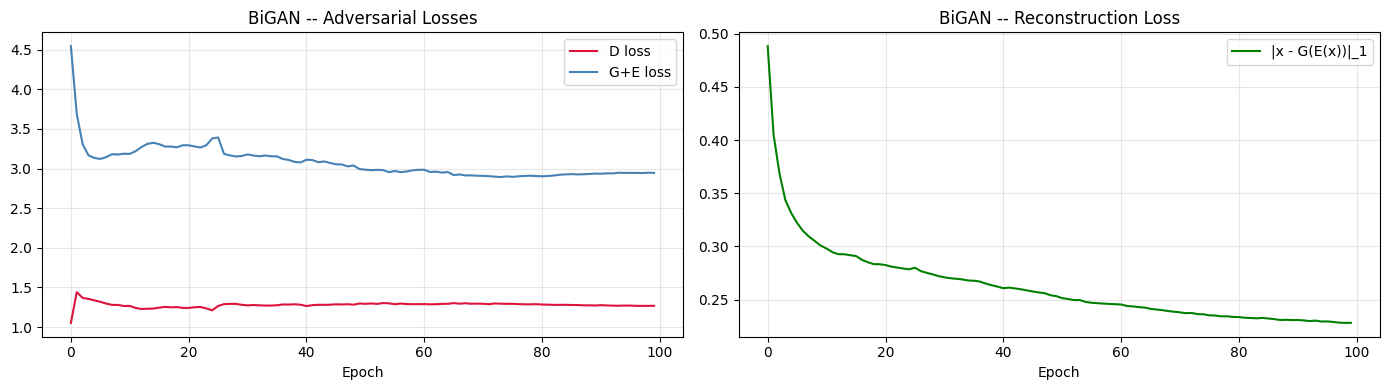

In [12]:
# Loss curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(hist_d,  color="crimson",   label="D loss")
axes[0].plot(hist_ge, color="steelblue", label="G+E loss")
axes[0].set_title("BiGAN -- Adversarial Losses"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_recon, color="green", label="|x - G(E(x))|_1")
axes[1].set_title("BiGAN -- Reconstruction Loss"); axes[1].set_xlabel("Epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 7.3 Anomaly Scoring

In [13]:
@torch.no_grad()
def bigan_anomaly_scores(X_tensor, G, E, D,
                         lambda_=BIGAN_LAMBDA,
                         latent_w=BIGAN_LATENT_W,
                         batch_size=4096):
    G.eval(); E.eval(); D.eval()
    scores = []
    n = X_tensor.size(0)
    for i in range(0, n, batch_size):
        x = X_tensor[i:i+batch_size]
        z      = E(x)
        x_rec  = G(z)
        z_rec  = E(x_rec)

        recon              = (x - x_rec).abs().mean(dim=1)
        latent_consistency = (z - z_rec).abs().mean(dim=1)

        _, f_real = D(x,     z, return_features=True)
        _, f_rec  = D(x_rec, z, return_features=True)   # use z (not z_rec)
        feat_match = (f_real - f_rec).abs().mean(dim=1)

        score = (1 - lambda_) * (recon + latent_w * latent_consistency) \
                + lambda_ * feat_match
        scores.append(score.detach().cpu().numpy())
    return np.concatenate(scores)


bigan_val_scores = bigan_anomaly_scores(X_val_tensor,  G_bi, E_bi, D_bi)
bigan_scores     = bigan_anomaly_scores(X_test_tensor, G_bi, E_bi, D_bi)

print(f"BiGAN val   scores : min={bigan_val_scores.min():.4f}  max={bigan_val_scores.max():.4f}")
print(f"BiGAN test  scores : min={bigan_scores.min():.4f}  max={bigan_scores.max():.4f}")
print(f"  test  normal mean+-std : {bigan_scores[y_test==0].mean():.4f} +- {bigan_scores[y_test==0].std():.4f}")
print(f"  test  fraud  mean+-std : {bigan_scores[y_test==1].mean():.4f} +- {bigan_scores[y_test==1].std():.4f}")

bigan_threshold = find_threshold_on_val(y_val, bigan_val_scores, "BiGAN")


BiGAN val   scores : min=0.0320  max=11.9324
BiGAN test  scores : min=0.0326  max=10.5662
  test  normal mean+-std : 0.1832 +- 0.1801
  test  fraud  mean+-std : 2.4807 +- 1.9325
[BiGAN] best validation threshold = 1.190925  (val F1 = 0.6361)


### 7.4 Evaluation

  BiGAN  --  Test Set Results
  Threshold : 1.190925
  Accuracy  : 0.9935
  Precision : 0.4630
  Recall    : 0.7886
  F1-Score  : 0.5835
  ROC-AUC   : 0.9553
  AUPRC     : 0.5946

  Confusion matrix:
[[42423   225]
 [   52   194]]

              precision    recall  f1-score   support

      Normal     0.9988    0.9947    0.9967     42648
       Fraud     0.4630    0.7886    0.5835       246

    accuracy                         0.9935     42894
   macro avg     0.7309    0.8917    0.7901     42894
weighted avg     0.9957    0.9935    0.9944     42894



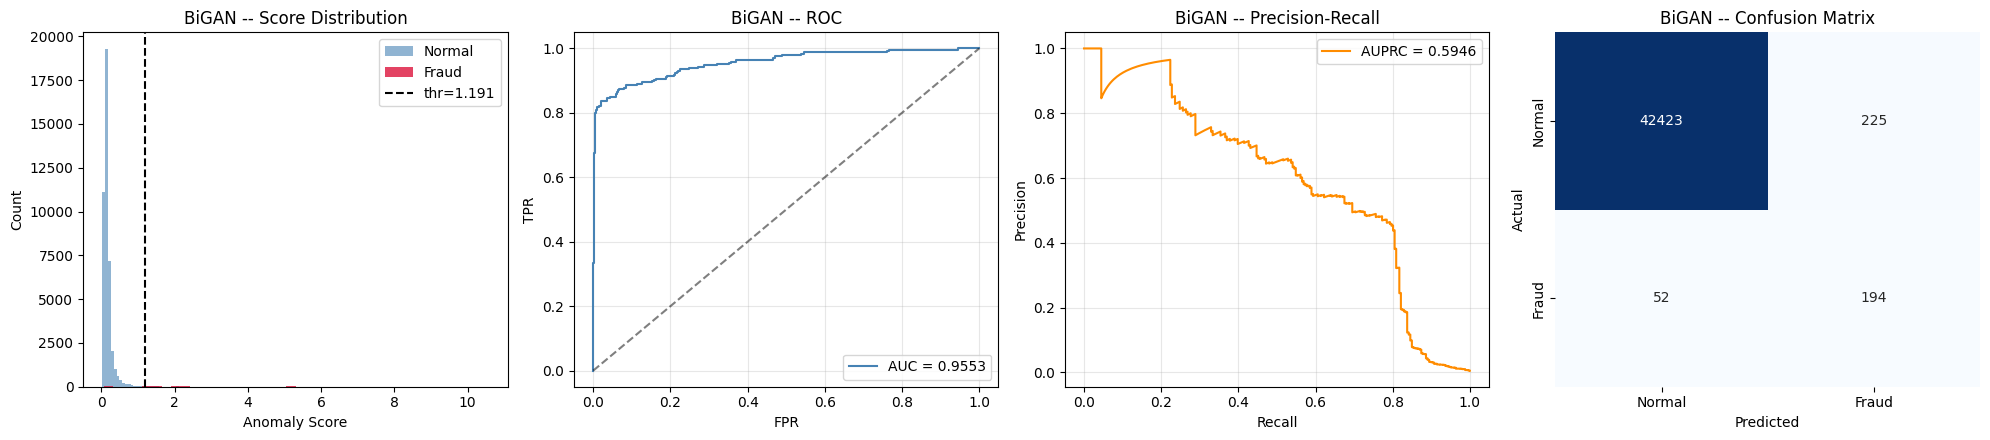

In [14]:
bigan_results = evaluate_model(y_test, bigan_scores, "BiGAN",
                               threshold=bigan_threshold)
plot_diagnostics(y_test, bigan_results)


## 8. AnoGAN (Anomaly GAN)

Standard GAN trained on normal data. At test time, each sample x* gets its anomaly score by iteratively optimising z to minimise:
$$ (1-\lambda)\|x^* - G(z)\|_2^2 + \lambda\|f_D(x^*) - f_D(G(z))\|_2^2 $$
The minimum loss value after `ANOGAN_Z_ITERS=500` Adam steps is the score.

### 8.1 Architecture

In [15]:
class AnoGAN_Generator(nn.Module):
    """z (32) -> x_hat (30) with Tanh output."""
    def __init__(self, latent_dim=LATENT_DIM, output_dim=INPUT_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Linear(256, output_dim),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class AnoGAN_Discriminator(nn.Module):
    """x (30) -> probability. Exposes 64-d 'features' for scoring."""
    def __init__(self, input_dim=INPUT_DIM):
        super().__init__()
        self.features = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
        )
        self.classifier = nn.Sequential(
            nn.Linear(64, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

    def get_features(self, x):
        return self.features(x)


G_ano = AnoGAN_Generator().to(DEVICE)
D_ano = AnoGAN_Discriminator().to(DEVICE)
print(f"AnoGAN G params: {n_params(G_ano):,}")
print(f"AnoGAN D params: {n_params(D_ano):,}")


AnoGAN G params: 52,062
AnoGAN D params: 49,153


### 8.2 Training

In [16]:
opt_G_ano = optim.Adam(G_ano.parameters(), lr=ANOGAN_LR_G, betas=(0.5, 0.999))
opt_D_ano = optim.Adam(D_ano.parameters(), lr=ANOGAN_LR_D, betas=(0.5, 0.999))
bce = nn.BCELoss()

ano_hist_d, ano_hist_g = [], []

t0 = time.time()
for epoch in range(ANOGAN_EPOCHS):
    G_ano.train(); D_ano.train()
    noise_std = ANOGAN_NOISE * max(0.0, 1 - epoch / ANOGAN_EPOCHS)

    e_d, e_g, n_batches = 0.0, 0.0, 0
    for (x_real,) in anogan_loader:
        x_real = x_real.to(DEVICE)
        bsz = x_real.size(0)
        smooth_ones = torch.full((bsz, 1), ANOGAN_SMOOTH, device=DEVICE)
        zeros = torch.zeros((bsz, 1), device=DEVICE)
        ones  = torch.ones ((bsz, 1), device=DEVICE)

        # ---- D update (N_CRITIC times) ----
        d_loss_val = 0.0
        for _ in range(ANOGAN_N_CRITIC):
            z = torch.randn(bsz, LATENT_DIM, device=DEVICE)
            x_fake = G_ano(z).detach()
            x_real_n = x_real + noise_std * torch.randn_like(x_real)
            x_fake_n = x_fake + noise_std * torch.randn_like(x_fake)

            d_loss = 0.5 * (bce(D_ano(x_real_n), smooth_ones)
                            + bce(D_ano(x_fake_n), zeros))
            opt_D_ano.zero_grad()
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(D_ano.parameters(), max_norm=5.0)
            opt_D_ano.step()
            d_loss_val = d_loss.item()

        # ---- G update ----
        z = torch.randn(bsz, LATENT_DIM, device=DEVICE)
        g_loss = bce(D_ano(G_ano(z)), ones)
        opt_G_ano.zero_grad()
        g_loss.backward()
        torch.nn.utils.clip_grad_norm_(G_ano.parameters(), max_norm=5.0)
        opt_G_ano.step()

        e_d += d_loss_val
        e_g += g_loss.item()
        n_batches += 1

    e_d /= n_batches; e_g /= n_batches
    ano_hist_d.append(e_d); ano_hist_g.append(e_g)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"[AnoGAN] epoch {epoch+1:3d}/{ANOGAN_EPOCHS}  "
              f"D={e_d:.4f}  G={e_g:.4f}  noise={noise_std:.3f}")

print(f"AnoGAN training time: {(time.time()-t0)/60:.2f} min")


[AnoGAN] epoch   1/100  D=0.6450  G=0.8769  noise=0.100
[AnoGAN] epoch  10/100  D=0.4871  G=1.4447  noise=0.091
[AnoGAN] epoch  20/100  D=0.4102  G=1.7576  noise=0.081
[AnoGAN] epoch  30/100  D=0.3888  G=1.9473  noise=0.071
[AnoGAN] epoch  40/100  D=0.3551  G=2.1985  noise=0.061
[AnoGAN] epoch  50/100  D=0.3308  G=2.4277  noise=0.051
[AnoGAN] epoch  60/100  D=0.3091  G=2.6485  noise=0.041
[AnoGAN] epoch  70/100  D=0.2902  G=2.8544  noise=0.031
[AnoGAN] epoch  80/100  D=0.2738  G=3.1043  noise=0.021
[AnoGAN] epoch  90/100  D=0.2571  G=3.4678  noise=0.011
[AnoGAN] epoch 100/100  D=0.2382  G=3.9407  noise=0.001
AnoGAN training time: 12.73 min


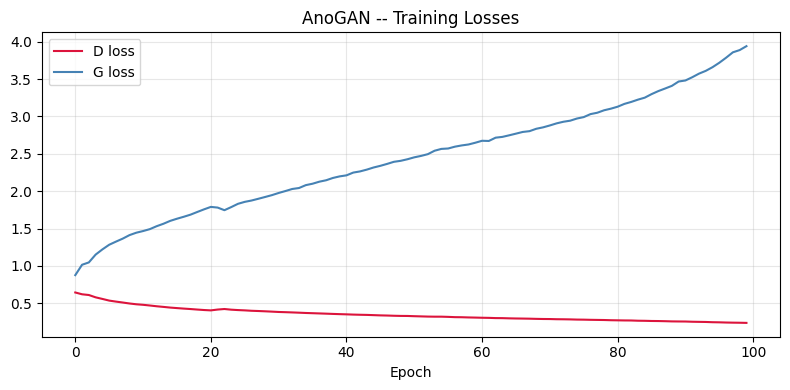

In [17]:
plt.figure(figsize=(8, 4))
plt.plot(ano_hist_d, color="crimson",   label="D loss")
plt.plot(ano_hist_g, color="steelblue", label="G loss")
plt.title("AnoGAN -- Training Losses"); plt.xlabel("Epoch")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


### 8.3 Anomaly Scoring (z-Optimisation)

For every test sample, run **500** Adam iterations on z to find the latent that best reconstructs x*.

In [18]:
def anogan_anomaly_scores(X_tensor, G, D, latent_dim,
                          lam=ANOGAN_LAMBDA,
                          n_iters=ANOGAN_Z_ITERS,
                          lr_z=ANOGAN_Z_LR,
                          opt_batch=ANOGAN_OPT_BS):
    G.eval(); D.eval()
    # Freeze
    for p in G.parameters(): p.requires_grad_(False)
    for p in D.parameters(): p.requires_grad_(False)

    n = X_tensor.size(0)
    all_scores = []
    n_total_batches = (n + opt_batch - 1) // opt_batch

    for b_idx, i in enumerate(range(0, n, opt_batch)):
        xb = X_tensor[i:i+opt_batch]
        bsz = xb.size(0)

        feat_real = D.get_features(xb).detach()

        z = torch.randn(bsz, latent_dim, device=xb.device, requires_grad=True)
        opt_z = optim.Adam([z], lr=lr_z)

        for _ in range(n_iters):
            x_hat     = G(z)
            residual  = torch.mean((xb - x_hat) ** 2, dim=1)
            feat_fake = D.get_features(x_hat)
            disc_loss = torch.mean((feat_real - feat_fake) ** 2, dim=1)
            loss = ((1 - lam) * residual + lam * disc_loss).mean()
            opt_z.zero_grad()
            loss.backward()
            opt_z.step()

        with torch.no_grad():
            x_hat     = G(z)
            residual  = torch.mean((xb - x_hat) ** 2, dim=1)
            feat_fake = D.get_features(x_hat)
            disc_loss = torch.mean((feat_real - feat_fake) ** 2, dim=1)
            score = (1 - lam) * residual + lam * disc_loss
        all_scores.append(score.detach().cpu().numpy())

        if (b_idx + 1) % 100 == 0:
            print(f"  AnoGAN scoring batch {b_idx+1}/{n_total_batches}")

    # Unfreeze
    for p in G.parameters(): p.requires_grad_(True)
    for p in D.parameters(): p.requires_grad_(True)

    return np.concatenate(all_scores)


print("Scoring validation set (z-optimisation, 500 iters/batch)...")
t0 = time.time()
anogan_val_scores = anogan_anomaly_scores(X_val_tensor, G_ano, D_ano, LATENT_DIM)
print(f"  done in {(time.time()-t0)/60:.2f} min")

print("Scoring test set...")
t0 = time.time()
anogan_scores = anogan_anomaly_scores(X_test_tensor, G_ano, D_ano, LATENT_DIM)
print(f"  done in {(time.time()-t0)/60:.2f} min")

print(f"AnoGAN val  scores : min={anogan_val_scores.min():.4f}  max={anogan_val_scores.max():.4f}")
print(f"AnoGAN test scores : min={anogan_scores.min():.4f}  max={anogan_scores.max():.4f}")
print(f"  test  normal mean+-std : {anogan_scores[y_test==0].mean():.4f} +- {anogan_scores[y_test==0].std():.4f}")
print(f"  test  fraud  mean+-std : {anogan_scores[y_test==1].mean():.4f} +- {anogan_scores[y_test==1].std():.4f}")

anogan_threshold = find_threshold_on_val(y_val, anogan_val_scores, "AnoGAN")


Scoring validation set (z-optimisation, 500 iters/batch)...
  AnoGAN scoring batch 100/225
  AnoGAN scoring batch 200/225
  done in 4.72 min
Scoring test set...
  AnoGAN scoring batch 100/336
  AnoGAN scoring batch 200/336
  AnoGAN scoring batch 300/336
  done in 6.81 min
AnoGAN val  scores : min=0.0009  max=1835.0341
AnoGAN test scores : min=0.0003  max=1129.3411
  test  normal mean+-std : 1.6563 +- 5.1046
  test  fraud  mean+-std : 149.6090 +- 193.6961
[AnoGAN] best validation threshold = 21.802780  (val F1 = 0.6869)


### 8.4 Evaluation

  AnoGAN  --  Test Set Results
  Threshold : 21.802780
  Accuracy  : 0.9955
  Precision : 0.5831
  Recall    : 0.7561
  F1-Score  : 0.6584
  ROC-AUC   : 0.9470
  AUPRC     : 0.6603

  Confusion matrix:
[[42515   133]
 [   60   186]]

              precision    recall  f1-score   support

      Normal     0.9986    0.9969    0.9977     42648
       Fraud     0.5831    0.7561    0.6584       246

    accuracy                         0.9955     42894
   macro avg     0.7908    0.8765    0.8281     42894
weighted avg     0.9962    0.9955    0.9958     42894



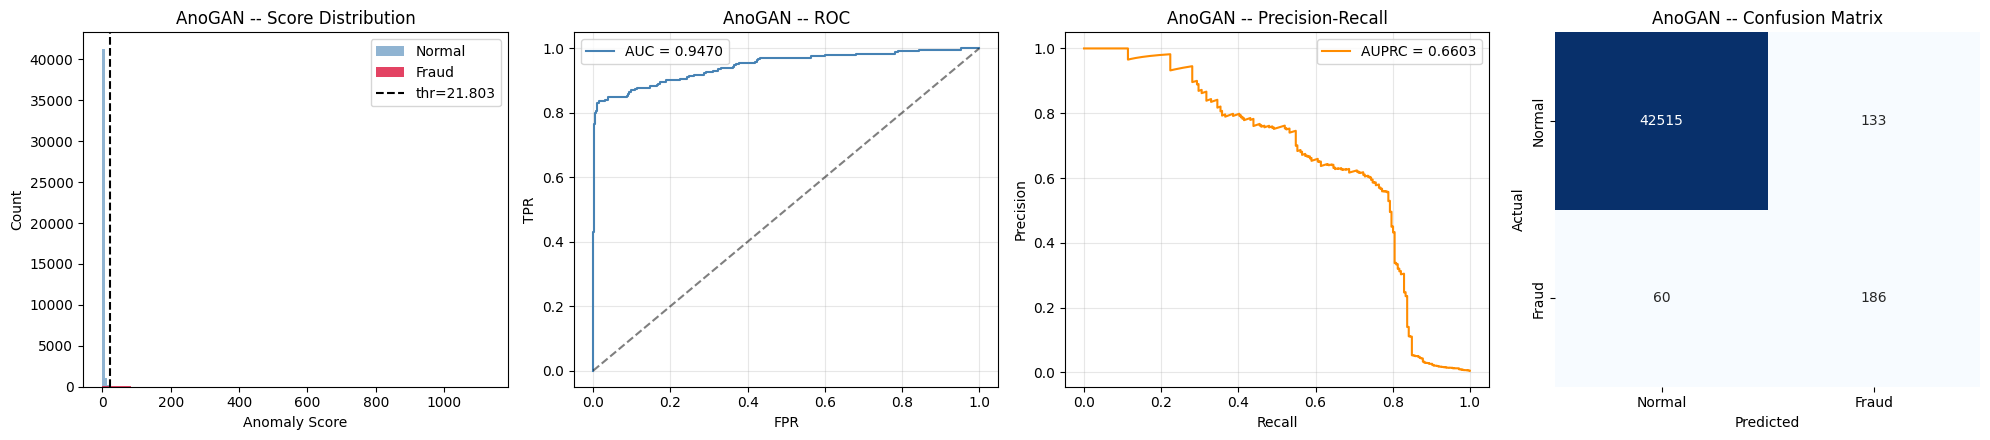

In [19]:
anogan_results = evaluate_model(y_test, anogan_scores, "AnoGAN",
                                threshold=anogan_threshold)
plot_diagnostics(y_test, anogan_results)


## 9. BiGAN vs AnoGAN -- Comparison

In [20]:
print("=" * 60)
print("  BiGAN vs AnoGAN  --  Test Set Comparison")
print("=" * 60)

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC", "AUPRC"],
    "BiGAN":  [bigan_results["accuracy"],
               bigan_results["precision"],
               bigan_results["recall"],
               bigan_results["f1"],
               bigan_results["roc_auc"],
               bigan_results["auprc"]],
    "AnoGAN": [anogan_results["accuracy"],
               anogan_results["precision"],
               anogan_results["recall"],
               anogan_results["f1"],
               anogan_results["roc_auc"],
               anogan_results["auprc"]],
})
comparison["BiGAN"]  = comparison["BiGAN"].map(lambda v: f"{v:.4f}")
comparison["AnoGAN"] = comparison["AnoGAN"].map(lambda v: f"{v:.4f}")
print(comparison.to_string(index=False))


  BiGAN vs AnoGAN  --  Test Set Comparison
   Metric  BiGAN AnoGAN
 Accuracy 0.9935 0.9955
Precision 0.4630 0.5831
   Recall 0.7886 0.7561
 F1-Score 0.5835 0.6584
  ROC-AUC 0.9553 0.9470
    AUPRC 0.5946 0.6603


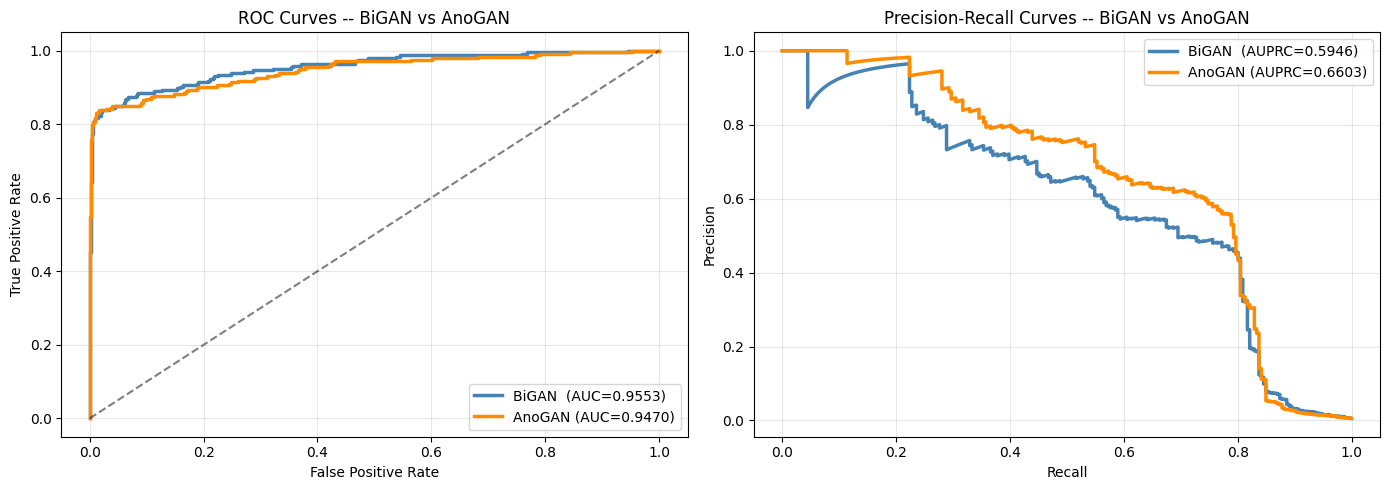

In [21]:
# Overlaid ROC + PR curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr_b, tpr_b, _ = roc_curve(y_test, bigan_scores)
fpr_a, tpr_a, _ = roc_curve(y_test, anogan_scores)
axes[0].plot(fpr_b, tpr_b, color="steelblue",  lw=2.5,
             label=f"BiGAN  (AUC={bigan_results['roc_auc']:.4f})")
axes[0].plot(fpr_a, tpr_a, color="darkorange", lw=2.5,
             label=f"AnoGAN (AUC={anogan_results['roc_auc']:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves -- BiGAN vs AnoGAN")
axes[0].legend(); axes[0].grid(alpha=0.3)

# PR
p_b, r_b, _ = precision_recall_curve(y_test, bigan_scores)
p_a, r_a, _ = precision_recall_curve(y_test, anogan_scores)
axes[1].plot(r_b, p_b, color="steelblue",  lw=2.5,
             label=f"BiGAN  (AUPRC={bigan_results['auprc']:.4f})")
axes[1].plot(r_a, p_a, color="darkorange", lw=2.5,
             label=f"AnoGAN (AUPRC={anogan_results['auprc']:.4f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves -- BiGAN vs AnoGAN")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


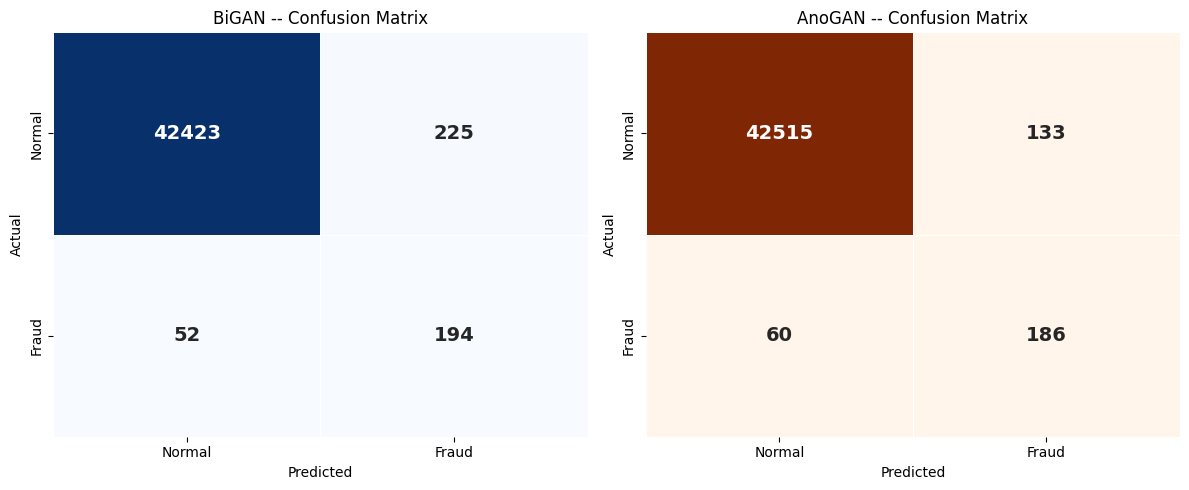

In [22]:
# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(bigan_results["confusion_matrix"], annot=True, fmt="d",
            cmap="Blues", ax=axes[0], cbar=False,
            xticklabels=["Normal", "Fraud"],
            yticklabels=["Normal", "Fraud"],
            annot_kws={"size": 14, "weight": "bold"},
            linewidths=0.5, linecolor="white")
axes[0].set_title("BiGAN -- Confusion Matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(anogan_results["confusion_matrix"], annot=True, fmt="d",
            cmap="Oranges", ax=axes[1], cbar=False,
            xticklabels=["Normal", "Fraud"],
            yticklabels=["Normal", "Fraud"],
            annot_kws={"size": 14, "weight": "bold"},
            linewidths=0.5, linecolor="white")
axes[1].set_title("AnoGAN -- Confusion Matrix")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()
